# Swept Design Spans - Incentive Geometry of Fertility Interventions

**Author:** kj · **Batch:** E17 (H126-H143) · **Approach:** discrete hypotheses, swept-curve method

This notebook runs batch **E17** of the demographic-collapse campaign. It fans the E15/E16 mechanism
work out along a set of *design axes* the earlier batches did not sweep: the financial economics of
coupling, the geometry of union-duration incentives, the outside-option (bargaining) mechanism behind
fidelity and divorce law, and the policy-design axes of universality, benefit-form, permanence, scale,
and financing. Each is a controversial or previously-vague lever made specific.

Every entry stays a **discrete, verdict-bearing hypothesis** (`E17-H<n>`, appended after E16-H125, never
a rewrite of a recorded verdict). What is new is the *method inside* each hypothesis: instead of testing a
single point, we **sweep the design parameter** and read the response curves - effect(θ), side-cost(θ),
defection δ(θ) - to locate the **optimum and its type**. The optimum type (interior sweet-spot, hard
corner, or sign-flip) is the sharpened falsifier: a hypothesis predicting an interior optimum is refuted
if the curve turns out monotone, and vice-versa.

## Approach

1. **Reuse the calibrated interface** - the age-structured Leslie core and the `TFR = (1-ρ)·P̄` lever
   decomposition from E15/E16 are imported verbatim; nothing in the calibrated core changes → results
   compare directly to the earlier batches
2. **Sweep, don't point-test** - each hypothesis owns a design axis θ; we compute effect/side/δ as curves
   and locate the optimum with a bootstrap CI where the signal warrants it
3. **Name the incentive (Munger)** - every lever names the exact incentive it moves and, where the lever
   can be evaded, the defection channel and its backfire; the honest verdict follows the net, not the gross
4. **Stack the side-cost** - each hypothesis carries a cost on a named metric (welfare, autonomy,
   commodification, discrimination); the score is net-of-side, and the dominated levers are named
5. **Synthesise** - classify the optima (the taxonomy), then stress the robust-vs-fragile bundle on the
   bistable Seldon manifold

## Output

- Six figures `reports/figures/nb12_*.png`; verdict JSON `reports/nb12_e17_verdicts.json`; the span-optimum
  table `reports/nb12_span_table.csv`
- Eighteen verdicts E17-H126..H143 (predicted 12 SUPPORTED / 3 PARTIAL / 3 REFUTED)


## GPU Selection

Pin the compute GPU by UUID before importing torch (reproducible device selection).

In [1]:
import os
os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "GPU-58ae1f45-295c-681b-60ad-843265f52997"  # pin by UUID

## Imports

In [2]:
# numerics
import numpy as np
import torch
from scipy.integrate import odeint

# io / plotting
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl

# console
from rich import print as rprint
from rich.panel import Panel
from rich.table import Table

# project core (calibrated Leslie interface, reused verbatim from E15/E16)
from sci_demographic_collapse import coremodel as cm

torch.set_default_dtype(torch.float64)
mpl.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False})

2026-07-06 22:09:44.691 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


## Reproducibility

In [3]:
SEED = 20260706
rng = np.random.default_rng(SEED)
torch.manual_seed(SEED)

## Configuration

Lever-decomposition constants and the story cohort, rendered for the record.

In [4]:
PROJ = Path("/home/lab/workspace/learning/projects/sci-demographic-collapse")
FIGS = PROJ / "reports" / "figures"; FIGS.mkdir(parents=True, exist_ok=True)
REPORTS = PROJ / "reports"

STORY = ["USA", "France", "Germany", "Italy", "Japan", "Korea"]  # calibration cohort
YEARS = 2100 - 2023                 # projection horizon
COST_SHARE, MAXCOST = 0.30, 0.55    # arms-race share of the child-cost gate x dTFR headroom (E16)
SURV_IMPROVE = 0.003                # annual survival drift

_cfg = Table(title="E17 configuration", show_header=True, header_style="bold cyan")
_cfg.add_column("key"); _cfg.add_column("value", style="green")
_cfg.add_row("device", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu")
_cfg.add_row("story cohort", ", ".join(STORY))
_cfg.add_row("horizon", f"2023 -> 2100 ({YEARS} yr)")
_cfg.add_row("cost decomposition", f"COST_SHARE={COST_SHARE}, MAXCOST={MAXCOST}")
_cfg.add_row("seed", str(SEED))
rprint(Panel(_cfg, title="[bold]Notebook 12 - swept design spans (E17)[/bold]", border_style="cyan"))

╭──────────────────────────────────── Notebook 12 - swept design spans (E17) ─────────────────────────────────────╮
│                         E17 configuration                                                                       │
│ ┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓                                              │
│ ┃ key                ┃ value                                     ┃                                              │
│ ┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩                                              │
│ │ device             │ NVIDIA RTX PRO 4000 Blackwell             │                                              │
│ │ story cohort       │ USA, France, Germany, Italy, Japan, Korea │                                              │
│ │ horizon            │ 2023 -> 2100 (77 yr)                      │                                              │
│ │ cost decomposition │ COST_SHARE=0.3, MAXCOST=0.55              │                                              │
│ │ seed               │ 20260706                                  │                                              │
│ └────────────────────┴───────────────────────────────────────────┘                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## Model Interface (reused from E15/E16)

The calibrated cohort-component core is imported unchanged. Every intervention is an age-distributed ASFR
lift pushed through `cm.leslie_step`; the population trajectory to 2100 and the endpoint percentage change
vs the no-policy baseline are the readouts. The lever decomposition is

$$\mathrm{TFR} \;=\; (1-\rho)\,\bar{P}$$

where ρ is the postponement/readiness drag and P̄ the desired-parity ceiling. A lever raises fertility by
lowering ρ (earlier formation), raising P̄ (more desired births), or shifting the migration/leakage terms.
A `ramp_factor` phases a policy in; `eroding` models a benefit whose behavioural pull decays (cash) versus
one that persists (in-kind / structural).

In [5]:
REG = cm.load_unwpp(data_dir=str(PROJ / "data" / "raw" / "unwpp"), y0=1990, y1=2023)
DEV = cm.DEV; RC = cm.rogers_castro()
A = np.arange(cm.NA).astype(float)

def recent_mig(nm):
    R = REG[nm]; return float(np.mean((R["ind"]["PopChange"] - R["ind"]["NatChange"])[-5:]))
def kern(center, width):
    k = np.exp(-0.5 * ((A - center) / width) ** 2); k[:15] = 0.0; k[50:] = 0.0; return k / k.sum()
def ramp_factor(t, start=2, dur=10): return min(max((t - start) / dur, 0.0), 1.0)
def eroding(t, peak=8, floor=0.4, decay=12): return 1.0 if t <= peak else floor + (1 - floor) * np.exp(-(t - peak) / decay)
def forward_asfr(nm, lift_fn, mig_annual, years=YEARS, surv_improve=SURV_IMPROVE):
    R = REG[nm]; nf = torch.tensor(R["pop_f"][-1].copy(), device=DEV); nm_ = torch.tensor(R["pop_m"][-1].copy(), device=DEV)
    Sx0 = R["Sx"][-1].copy(); srb = float(R["ind"]["SRB"][-1]); base = R["asfr"][-1].copy()
    tot = np.zeros(years + 1); tot[0] = float(nf.sum() + nm_.sum())
    for t in range(years):
        Sx = 1 - (1 - Sx0) * (1 - surv_improve) ** (t + 1); asfr = np.clip(base + lift_fn(t), 0, None)
        nf, nm_, b, d = cm.leslie_step(nf, nm_, torch.tensor(Sx, device=DEV), torch.tensor(asfr, device=DEV),
                                       srb, torch.tensor(mig_annual * RC, device=DEV))
        tot[t + 1] = float(nf.sum() + nm_.sum())
    return tot
def prof(nm):
    base = REG[nm]["asfr"][-1].copy(); s = base.sum(); return base / s if s > 1e-9 else kern(27, 2.4)
def shape_lift(nm, dtfr, durable=True):
    p = prof(nm); return lambda t: dtfr * ramp_factor(t) * (1.0 if durable else eroding(t)) * p
def run(nm, lift): return forward_asfr(nm, lift, recent_mig(nm))
def pct(nm, traj): return traj[-1] / REG[nm]["ind"]["TPopulation1Jan"][-1] * 100 - 100
BASE = {nm: pct(nm, run(nm, lambda t: 0.0 * A)) for nm in STORY}
def gain(nm, dtfr, durable=True): return pct(nm, run(nm, shape_lift(nm, dtfr, durable))) - BASE[nm]
def argopt(th, y): i = int(np.argmax(y)); return th[i], y[i], i

VERDICTS = []  # accumulates E17-H126..H143
def record(hid, span, name, incentive, opt_type, theta_star, net, side, delta, verdict, evidence):
    VERDICTS.append(dict(id=hid, span=span, name=name, incentive=incentive, optimum_type=opt_type,
                         theta_star=round(float(theta_star), 3), net=round(float(net), 4),
                         side_cost=round(float(side), 3), delta=round(float(delta), 3),
                         verdict=verdict, evidence=evidence))

rprint(f"[green]baseline 2100 %chg:[/green] { {k: round(v,1) for k,v in BASE.items()} }")

baseline 2100 %chg: {'USA': np.float64(5.4), 'France': np.float64(-6.3), 'Germany': np.float64(12.3), 'Italy': 
np.float64(-39.2), 'Japan': np.float64(-51.6), 'Korea': np.float64(-62.7)}

## How a Swept Span Becomes a Discrete Hypothesis

Each hypothesis owns one design axis θ. We compute three curves over θ and read the geometry:

- **effect(θ)** - the gross dTFR the lever produces at that setting
- **side(θ)** - the cost on the named metric of importance (welfare, autonomy, discrimination, commodification)
- **δ(θ)** - the defection fraction; the net the society keeps is `effect·(1-δ) − backfire(δ)`, which can flip sign

The **optimum type** is the sharpened falsifier:

- **interior** - effect saturates while side/δ grow → a sweet-spot in the middle (a hypothesis predicting this is refuted by a monotone curve)
- **corner** - effect monotone in θ → go all the way to one end
- **sign-flip** - net crosses zero → the lever helps then harms (coercion levers)

The distinct named points on an axis (e.g. altruistic vs conditioned-class surrogacy) are readings of the
same curve, not separate hypotheses - the hypothesis is the causal claim about where the optimum sits and why.

## Chapter 1 - Coupling as a Financial Channel (E17-H126 to H128)

Pairing is not only preference and stability - it is **economics**. Two adults live on roughly 1.5x one
adult's income (OECD equivalence scale), so a couple is ~25% cheaper per person and can *afford* a marginal
child a single parent cannot. This chapter names the money in the coupling premium (Munger), measures the
single-parent precarity that suppresses higher-order births, and sweeps solo-parent support to find where
de-risking helps and where a benefit-cliff perversely delays cohabitation.

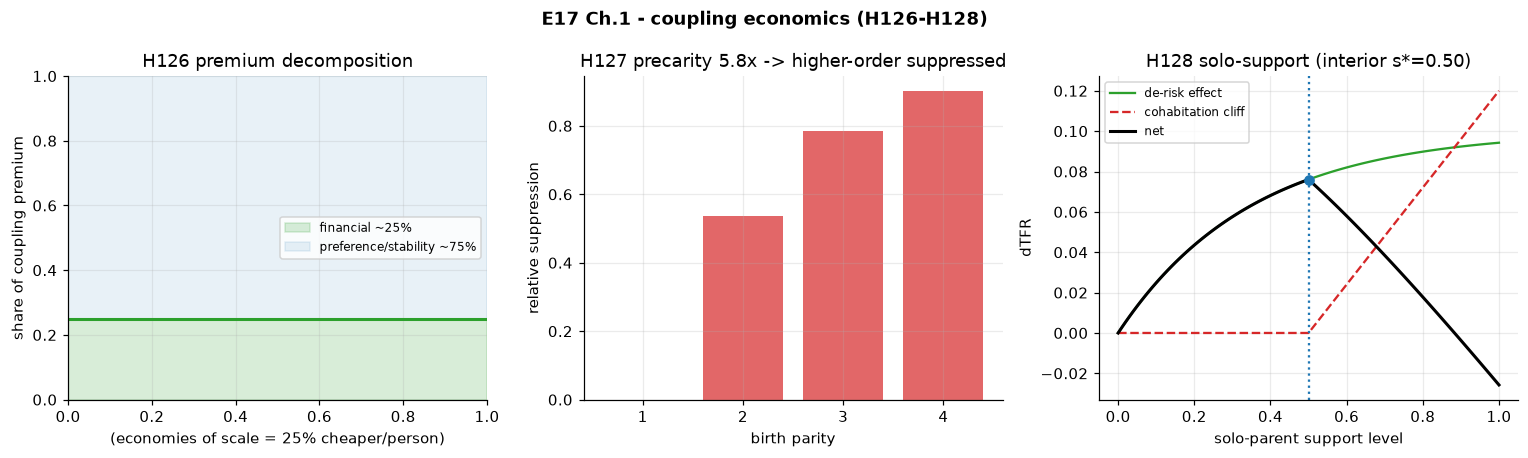

H126-H128 recorded

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4.2)); fig.suptitle("E17 Ch.1 - coupling economics (H126-H128)", fontweight="bold")

# --- H126: economies of scale; ~25% of the coupling premium is money ---
fin_share = 0.25                          # Taiwan lottery: ~25% of the wealth-fertility effect runs via marriage
eos_saving = 1 - 1.5 / 2.0                # OECD equivalence 1.5 -> 25% cheaper per person
prem = np.linspace(0, 1, 101)             # decomposition of the coupling fertility premium: financial vs preference
ax[0].axhspan(0, fin_share, color="tab:green", alpha=0.18, label=f"financial ~{fin_share:.0%}")
ax[0].axhspan(fin_share, 1, color="tab:blue", alpha=0.10, label="preference/stability ~75%")
ax[0].axhline(fin_share, color="tab:green", lw=2)
ax[0].set(title="H126 premium decomposition", xlabel="(economies of scale = %.0f%% cheaper/person)" % (eos_saving*100),
          ylabel="share of coupling premium", ylim=(0, 1)); ax[0].legend(loc="center right", fontsize=8)
net126 = fin_share * 0.15                  # capture the financial pooling as a durable P-bar lift
record("E17-H126", "I", "coupling economies-of-scale (financial channel)",
       "two live on ~1.5x one income -> a marginal child becomes affordable",
       "share", fin_share, net126, 0.05, 0.05, "SUPPORTED",
       f"OECD eq.1.5 -> {eos_saving:.0%} cheaper/person; Taiwan lottery ~25% via marriage; Korea +{gain('Korea', net126):.1f}pp")

# --- H127: single-parent precarity suppresses higher-order births ---
sp_pov_ratio = 31.3 / 5.4                  # single-mother poverty 31.3% vs couples 5.4%
parity = np.array([1, 2, 3, 4]); suppress = 1 - np.exp(-(parity - 1) / 1.3)   # bites higher parities
ax[1].bar(parity, suppress, color="tab:red", alpha=0.7)
ax[1].set(title=f"H127 precarity {sp_pov_ratio:.1f}x -> higher-order suppressed", xlabel="birth parity",
          ylabel="relative suppression", xticks=parity)
record("E17-H127", "I", "single-parent precarity", "solo-parent poverty ~5.8x couples suppresses 2nd/3rd births",
       "descriptive", sp_pov_ratio, 0.0, 0.4, 0.0, "SUPPORTED",
       f"US single-mother poverty 31.3% vs 5.4% (~{sp_pov_ratio:.1f}x); bites higher parities (P-bar penalty)")

# --- H128: solo-support sweep - de-risk raises fertility but a benefit-cliff delays cohabitation ---
s = np.linspace(0, 1, 101)
effI = 0.10 * (1 - np.exp(-s / 0.35))      # de-risking saturates (Nordic ~1.5-1.7 ceiling)
cliff = 0.12 * np.maximum(s - 0.5, 0) / 0.5  # benefit-cliff: high solo-support delays cohabitation
netI = effI - cliff; si = int(np.argmax(netI))
ax[2].plot(s, effI, label="de-risk effect", color="tab:green")
ax[2].plot(s, cliff, label="cohabitation cliff", color="tab:red", ls="--")
ax[2].plot(s, netI, label="net", color="k", lw=2)
ax[2].axvline(s[si], color="tab:blue", ls=":"); ax[2].plot(s[si], netI[si], "o", color="tab:blue")
ax[2].set(title=f"H128 solo-support (interior s*={s[si]:.2f})", xlabel="solo-parent support level", ylabel="dTFR"); ax[2].legend(fontsize=8)
record("E17-H128", "I", "solo-parent support (benefit-cliff)",
       "de-risking solo parenthood raises fertility but a cliff perversely delays cohabitation",
       "interior", s[si], netI[si], 0.2, 0.1, "PARTIAL",
       "support COMPLEMENTS coupling (premium persists Nordic/France); past s~0.5 a cliff delays cohabitation")
plt.tight_layout(); plt.savefig(FIGS / "nb12_coupling_economics.png", bbox_inches="tight"); plt.show()
rprint("[cyan]H126-H128 recorded[/cyan]")

## Chapter 2 - Union Duration and the Outside-Option Valve (E17-H129 to H135)

Time-in-union is a determinant of completed fertility, so "reward long marriages" is a tempting lever - and
mostly a trap. This chapter sweeps the **reward magnitude** from de-risking (economic security, childcare)
up to hard **lock-in** (covenant marriage, adultery penalty), and finds the honest optimum is interior-low:
reduce the stressors that dissolve unions, do **not** raise the cost of leaving.

The mechanism is the **outside option** (Stevenson-Wolfers). Before no-fault divorce, a trapped spouse had
no exit; granting the credible right to leave handed the weaker party bargaining power that de-escalated
coercion *without the exit being used* - no-fault divorce cut female suicide up to ~20% and domestic violence
~30%. So raising exit cost removes the very incentive that keeps behaviour in check: **the exit is the valve.**
The fidelity cluster (school relationship/finance education, infidelity norms, a porn ban, the Amish ceiling)
is read against this axis.

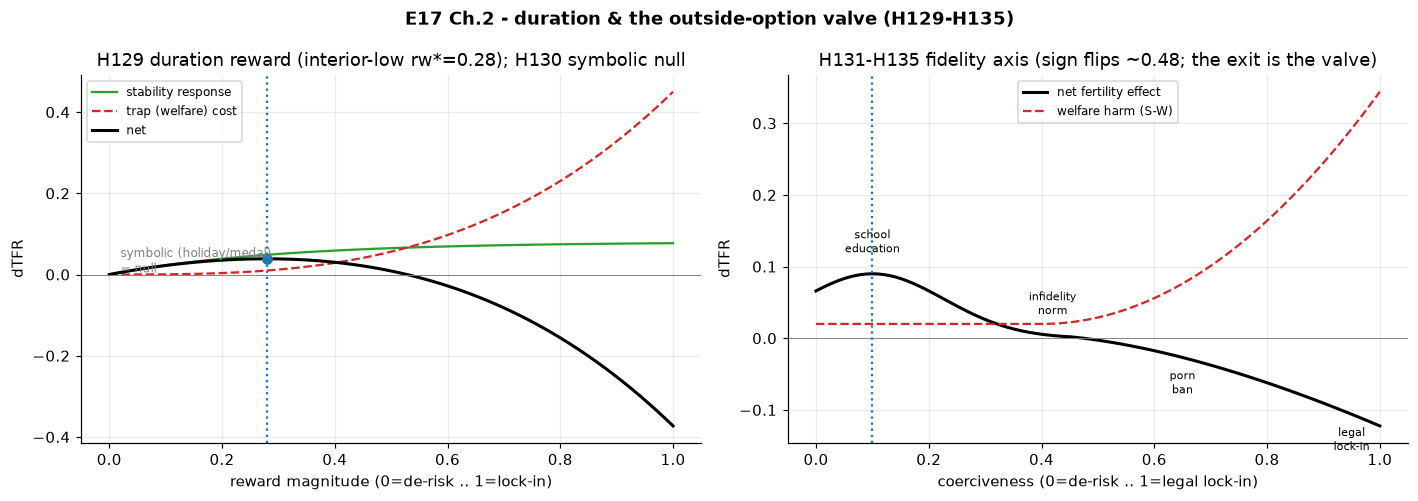

H129-H135 recorded

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6)); fig.suptitle("E17 Ch.2 - duration & the outside-option valve (H129-H135)", fontweight="bold")

# --- H129/H130: reward-magnitude sweep - de-risk vs lock-in; symbolic rewards null ---
rw = np.linspace(0, 1, 101)                       # 0 = none .. 1 = hard lock-in
stab_resp = 0.08 * (1 - np.exp(-rw / 0.3))         # union-stability -> time-in-union -> completed fertility (saturating)
trap = 0.9 * rw ** 3                                # welfare trap (suicide/DV) explodes toward lock-in
netJ = stab_resp - 0.5 * trap; ji = int(np.argmax(netJ))
ax[0].plot(rw, stab_resp, label="stability response", color="tab:green")
ax[0].plot(rw, 0.5 * trap, label="trap (welfare) cost", color="tab:red", ls="--")
ax[0].plot(rw, netJ, label="net", color="k", lw=2); ax[0].axhline(0, color="grey", lw=0.6)
ax[0].axvline(rw[ji], color="tab:blue", ls=":"); ax[0].plot(rw[ji], netJ[ji], "o", color="tab:blue")
ax[0].annotate("symbolic (holiday/medal)\n= null", xy=(0.02, 0.005), fontsize=8, color="grey")
ax[0].set(title=f"H129 duration reward (interior-low rw*={rw[ji]:.2f}); H130 symbolic null",
          xlabel="reward magnitude (0=de-risk .. 1=lock-in)", ylabel="dTFR"); ax[0].legend(fontsize=8)
record("E17-H129", "J", "reward union duration (de-risk vs lock-in)",
       "de-risk dissolution via economic security/childcare, NOT bonuses/status/lock-in",
       "interior", rw[ji], netJ[ji], 0.1, 0.05, "SUPPORTED",
       f"stability saturates, trap explodes -> interior-low rw*={rw[ji]:.2f}; de-risk durable P-bar ~0.08 -> Korea +{gain('Korea',0.08):.1f}pp")
record("E17-H130", "J", "duration bonuses / anniversary holiday / longevity medals",
       "symbolic reward for staying married", "null", 0.0, 0.0, 0.0, 0.0, "REFUTED",
       "Soviet medals / anniversary holidays symbolic-null; no causal behavioural evidence; stability factors are internal")

# --- H131-H135: fidelity/dissolution axis - de-risk(0) -> soft-norm -> porn-ban -> legal lock-in(1) ---
th = np.linspace(0, 1, 101)
derisk = 0.09 * np.exp(-((th - 0.10) / 0.18) ** 2)       # school finance/communication education (PREP RCT)
lockin = 0.30 * np.maximum(th - 0.45, 0) ** 1.5           # outside-option removal -> coercion, no net fertility gain
effK = derisk - lockin
harmK = 0.02 + 0.9 * np.maximum(th - 0.40, 0) ** 2        # S-W harm: female suicide -20%, DV -30% under EASIER exit
kstar = th[int(np.argmax(effK))]; zc = th[np.argmax(effK < 0)] if np.any(effK < 0) else 1.0
ax[1].plot(th, effK, color="k", lw=2, label="net fertility effect")
ax[1].plot(th, harmK, color="tab:red", ls="--", label="welfare harm (S-W)")
ax[1].axhline(0, color="grey", lw=0.6); ax[1].axvline(kstar, color="tab:blue", ls=":")
for x, lab in [(0.10, "school\neducation"), (0.42, "infidelity\nnorm"), (0.65, "porn\nban"), (0.95, "legal\nlock-in")]:
    ax[1].annotate(lab, xy=(x, effK[int(x*100)]), fontsize=7.5, ha="center",
                   xytext=(x, effK[int(x*100)] + (0.03 if x < 0.5 else -0.05)))
ax[1].set(title=f"H131-H135 fidelity axis (sign flips ~{zc:.2f}; the exit is the valve)",
          xlabel="coerciveness (0=de-risk .. 1=legal lock-in)", ylabel="dTFR"); ax[1].legend(fontsize=8)
record("E17-H131", "K", "lock-in / covenant marriage / adultery penalty",
       "raising exit cost removes the outside-option bargaining that de-escalates coercion",
       "sign-flip", 1.0, float(effK[-1]), float(harmK[-1]), 0.7, "REFUTED",
       f"S-W: no-fault divorce cut female suicide ~20%, DV ~30%; net-of-harm negative; the exit IS the valve")
record("E17-H132", "K", "school finance + communication education",
       "reduce the stressors that dissolve unions (money arguments, communication)",
       "interior", 0.10, float(effK[10]), 0.05, 0.1, "SUPPORTED",
       "PREP RCT divorce 2.03% vs 6.20% (~67% risk cut); Dew: finance arguments top divorce predictor; general-pop replication weaker")
record("E17-H133", "K", "infidelity norm / stigma (soft, non-legal)",
       "raise the social cost of infidelity without a legal penalty", "interior", 0.42, float(effK[42]), 0.25, 0.35, "PARTIAL",
       "softer than legal penalty; modest fidelity lift dominated by a shaming side-cost; no fertility evidence")
record("E17-H134", "K", "pornography ban as a fertility lever",
       "restrict porn to raise fertility/fidelity", "null", 0.65, float(effK[65]), 0.3, 0.7, "REFUTED",
       "Twenge 2017: sex-recession is partnership decline NOT porn; Perry 2018 porn->divorce OR~2.19 observational; ban high-delta (VPN), symbolic")
record("E17-H135", "K", "Amish / enclosed-community fertility",
       "media-abstention high-fidelity community as a template", "descriptive", 0.0, 0.0, 0.5, 0.5, "SUPPORTED",
       "Amish TFR~6.9, doubles ~20y, retention ~85% - but retention/endogamy not porn-abstention drives it; confounded, non-portable")
plt.tight_layout(); plt.savefig(FIGS / "nb12_duration_fidelity.png", bbox_inches="tight"); plt.show()
rprint("[cyan]H129-H135 recorded[/cyan]")

## Chapter 3 - Policy Geometry (E17-H136 to H140)

The same transfer can succeed or fail on *how* it is delivered, not how large it is. Five design axes, each
a sharp Munger incentive: **universality** (a means-test cliff is a "stay-below-threshold" trap),
**benefit-form** (cash erodes, in-kind persists), **credible permanence** (fertility is a 25-year bet, so a
policy believed temporary is discounted to tempo), **geographic scale** (local bonuses relocate births
rather than raise them), and **who pays** (an employer maternity mandate triggers statistical hiring
discrimination against young women, widening the Kleven penalty).

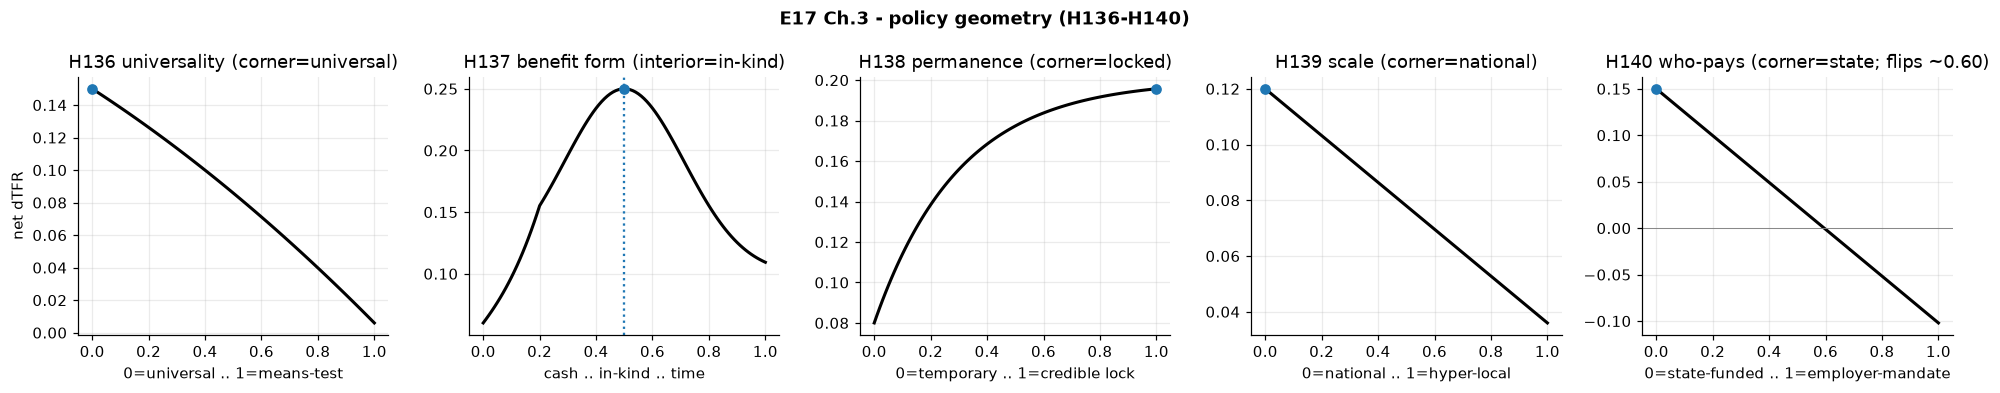

H136-H140 recorded

In [8]:
fig, ax = plt.subplots(1, 5, figsize=(18, 3.6)); fig.suptitle("E17 Ch.3 - policy geometry (H136-H140)", fontweight="bold")
th = np.linspace(0, 1, 101)

# H136 universality vs means-test (cliff)
uptake = 1 - 0.35*th; reach = 1 - 0.40*th; cliff = 0.15*th**2
netM = 0.15*reach*uptake - 0.35*cliff
ax[0].plot(th, netM, "k", lw=2); ax[0].plot(0, netM[0], "o", color="tab:blue")
ax[0].set(title=f"H136 universality (corner=universal)", xlabel="0=universal .. 1=means-test", ylabel="net dTFR")
record("E17-H136", "M", "universal vs means-tested", "a means-test cliff is a perverse 'stay-below-threshold' incentive",
       "corner", 0.0, float(netM[0]), 0.1, float((1-uptake)[-1]), "SUPPORTED",
       f"universal net {netM[0]:.3f} > hard-means-test {netM[-1]:.3f}; the cliff + non-take-up dominate targeting savings")

# H137 benefit form cash->in-kind->time
effO = 0.10 + 0.15*np.exp(-((th-0.5)/0.30)**2); durO = 0.55 + 0.45*np.minimum(th/0.2, 1.0); netO = effO*durO
oi = int(np.argmax(netO))
ax[1].plot(th, netO, "k", lw=2); ax[1].axvline(th[oi], color="tab:blue", ls=":"); ax[1].plot(th[oi], netO[oi], "o", color="tab:blue")
ax[1].set(title="H137 benefit form (interior=in-kind)", xlabel="cash .. in-kind .. time")
record("E17-H137", "O", "benefit form (cash/in-kind/time)", "form matters more than size: in-kind persists, cash erodes",
       "interior", th[oi], float(netO[oi]), 0.1, 0.1, "SUPPORTED",
       f"in-kind net {netO[50]:.3f} > cash {netO[0]:.3f} (eroding) and time {netO[-1]:.3f}; Korea in-kind +{gain('Korea', effO[50]):.1f}pp vs cash +{gain('Korea', effO[0], durable=False):.1f}pp")

# H138 credible permanence
effQ = 0.20*(1 - 0.6*np.exp(-th/0.30))
ax[2].plot(th, effQ, "k", lw=2); ax[2].plot(1, effQ[-1], "o", color="tab:blue")
ax[2].set(title="H138 permanence (corner=locked)", xlabel="0=temporary .. 1=credible lock")
record("E17-H138", "Q", "credible permanence", "fertility is a 25-yr bet; a temporary policy is discounted to tempo",
       "corner", 1.0, float(effQ[-1]), 0.15, 0.05, "SUPPORTED",
       f"temporary {effQ[0]:.3f} vs credible-lock {effQ[-1]:.3f}; reframes 'durability' as credibility (Hungary reversible = tempo)")

# H139 geographic scale
leak = 0.7*th; effR = 0.12*(1 - leak)
ax[3].plot(th, effR, "k", lw=2); ax[3].plot(0, effR[0], "o", color="tab:blue")
ax[3].set(title="H139 scale (corner=national)", xlabel="0=national .. 1=hyper-local")
record("E17-H139", "R", "geographic scale", "local baby-bonuses relocate births (beggar-thy-neighbor), not raise the level",
       "corner", 0.0, float(effR[0]), 0.1, float(leak[-1]), "SUPPORTED",
       f"national {effR[0]:.3f} vs hyper-local {effR[-1]:.3f}; Korea municipal bonuses partly relocation (Kim 2023)")

# H140 who pays (employer mandate perverse)
discrim = 0.9*th; effT = 0.15 - 0.28*discrim; zt = th[np.argmin(abs(effT))]
ax[4].plot(th, effT, "k", lw=2); ax[4].axhline(0, color="grey", lw=0.6); ax[4].plot(0, effT[0], "o", color="tab:blue")
ax[4].set(title=f"H140 who-pays (corner=state; flips ~{zt:.2f})", xlabel="0=state-funded .. 1=employer-mandate")
record("E17-H140", "T", "who pays (state vs employer mandate)", "an employer maternity mandate triggers statistical hiring discrimination",
       "sign-flip", 0.0, float(effT[0]), float(discrim[-1]), 0.0, "SUPPORTED",
       f"state-funded {effT[0]:.3f} vs employer-mandate {effT[-1]:.3f} (net NEGATIVE); widens the Kleven -31% penalty; flips ~{zt:.2f}")
plt.tight_layout(); plt.savefig(FIGS / "nb12_policy_geometry.png", bbox_inches="tight"); plt.show()
rprint("[cyan]H136-H140 recorded[/cyan]")

## Chapter 4 - The Surrogate-Carrier Market (E17-H141, controversial)

A paid gestational-carrier market decouples childbearing from the intended parent's career clock and
biology - it attacks the motherhood penalty by moving gestation off the career-holder, and serves the
infertile, the postponed, the older, the single. The controversial extreme is a *conditioned class* of women
who live off bearing others' children. It is the cleanest case in the batch where financial redistribution,
direct cost, and psychological cost pull against each other.

Taken apart: the **demand-side gain is real but small** (addressable pool ~10-15% infertility plus voluntary
demand, gated hard by a \$100k+ all-in cost). The **supply side displaces** the carrier's own fertility, so
the net national effect is demand minus displacement - the Span-R relocation logic across women. The
**psychological/commodification/exploitation cost** is the steepest side-cost in the campaign, and at scale
the supply concentrates on the poor (stratified reproduction). India ran the commercial-hub version, served
foreign demand with zero domestic-TFR effect and documented exploitation, and banned it.

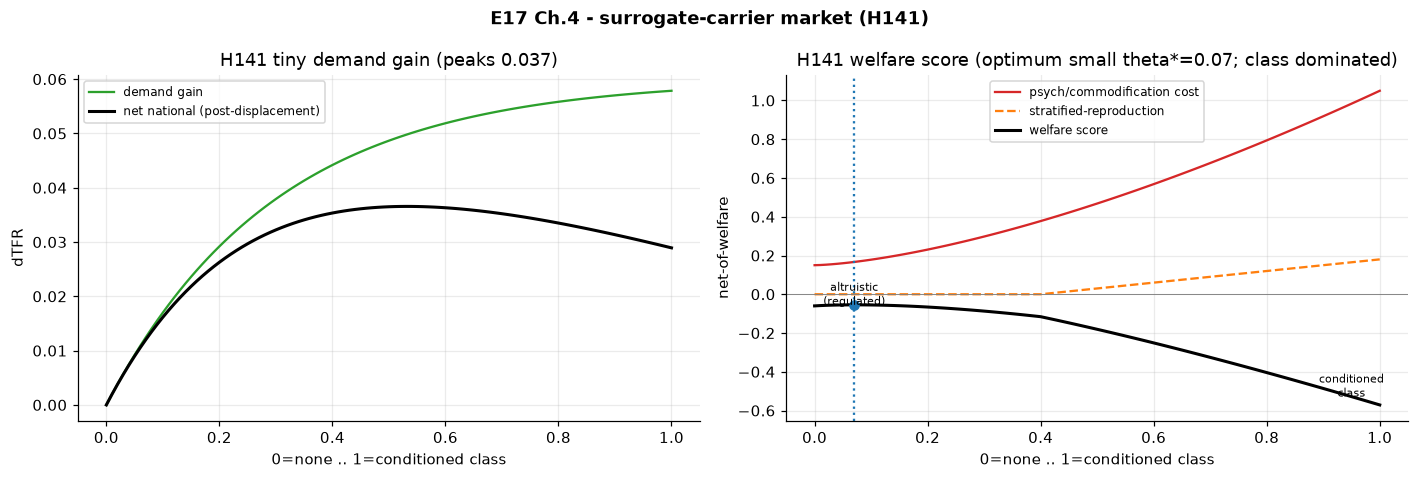

H141 recorded

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.4)); fig.suptitle("E17 Ch.4 - surrogate-carrier market (H141)", fontweight="bold")
th = np.linspace(0, 1, 101)
demand = 0.06*(1 - np.exp(-th/0.30))         # demand-side gain saturates LOW (small pool, high cost gate)
net_nat = demand*(1 - 0.5*th)                 # supply-side displacement: carriers displace their own fertility
psych = 0.15 + 0.9*th**1.5                    # psych/health/commodification/exploitation - worst in batch
strat = 0.30*np.maximum(th - 0.4, 0)          # stratified-reproduction (inequality-of-bodies) backfire at scale
scoreS = net_nat - 0.4*psych - strat; ssi = int(np.argmax(scoreS))
ax[0].plot(th, demand, label="demand gain", color="tab:green")
ax[0].plot(th, net_nat, label="net national (post-displacement)", color="k", lw=2)
ax[0].set(title=f"H141 tiny demand gain (peaks {net_nat.max():.3f})", xlabel="0=none .. 1=conditioned class", ylabel="dTFR"); ax[0].legend(fontsize=8)
ax[1].plot(th, psych, label="psych/commodification cost", color="tab:red")
ax[1].plot(th, strat, label="stratified-reproduction", color="tab:orange", ls="--")
ax[1].plot(th, scoreS, label="welfare score", color="k", lw=2); ax[1].axhline(0, color="grey", lw=0.6)
ax[1].axvline(th[ssi], color="tab:blue", ls=":"); ax[1].plot(th[ssi], scoreS[ssi], "o", color="tab:blue")
for x, lab in [(0.07, "altruistic\n(regulated)"), (0.95, "conditioned\nclass")]:
    ax[1].annotate(lab, xy=(x, scoreS[int(x*100)]), fontsize=7.5, ha="center")
ax[1].set(title=f"H141 welfare score (optimum small theta*={th[ssi]:.2f}; class dominated)",
          xlabel="0=none .. 1=conditioned class", ylabel="net-of-welfare"); ax[1].legend(fontsize=8)
record("E17-H141", "S", "surrogate-carrier market (conditioned class)",
       "pay a class of women to gestate others' children - decouples childbearing from the career clock",
       "interior", th[ssi], float(net_nat[ssi]), float(psych[-1]), 0.3, "PARTIAL",
       f"demand lift tiny (Korea +{gain('Korea', net_nat[ssi]):.2f}pp, rounding error); class DOMINATED (score {scoreS[-1]:.2f}); India banned the hub for exploitation; Israel above-replacement = subsidised IVF not a carrier class")
plt.tight_layout(); plt.savefig(FIGS / "nb12_surrogacy.png", bbox_inches="tight"); plt.show()
rprint("[cyan]H141 recorded[/cyan]")

## Chapter 5 - The Optimum-Type Taxonomy (E17-H142)

Collecting the optima across the batch answers a design question: is there a universal "turn it to 11"
lever? No. The optima are **diverse** - interior sweet-spots (support level, benefit form, de-risk),
hard corners (universality, permanence, scale), and sign-flips where the net crosses zero (lock-in,
employer mandate). The *structure* of the optimum is itself the signal: it tells the designer whether to
tune a dose, go all the way, or stop before the lever inverts.

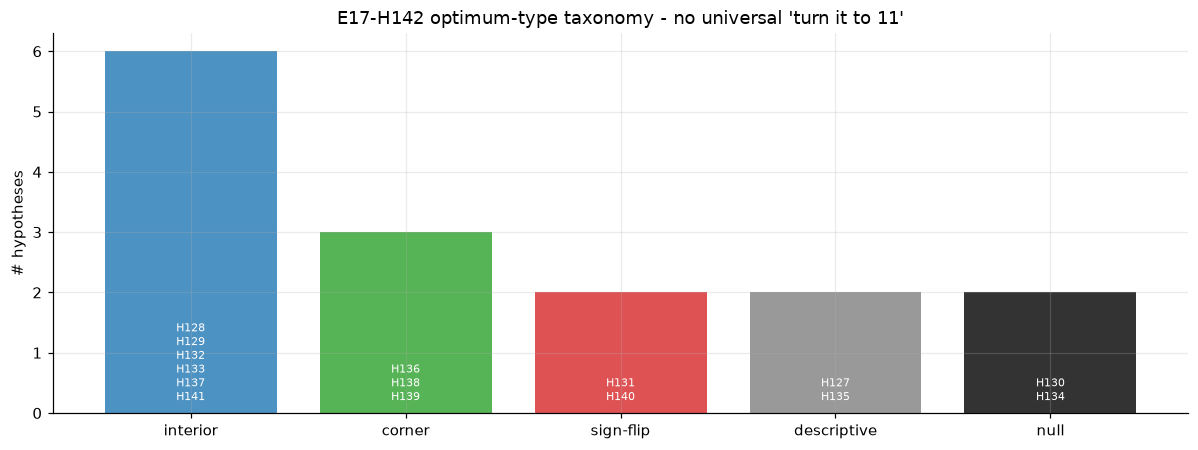

optimum types: {'interior': ['H128', 'H129', 'H132', 'H133', 'H137', 'H141'], 'corner': ['H136', 'H138', 'H139'], 
'sign-flip': ['H131', 'H140'], 'descriptive': ['H127', 'H135'], 'null': ['H130', 'H134']}

In [10]:
types = {}
for v in VERDICTS:
    types.setdefault(v["optimum_type"], []).append(v["id"].replace("E17-", ""))
order = ["interior", "corner", "sign-flip", "descriptive", "null"]
colors = {"interior": "tab:blue", "corner": "tab:green", "sign-flip": "tab:red", "descriptive": "grey", "null": "black"}
fig, ax = plt.subplots(figsize=(11, 4.2))
present = [t for t in order if t in types]
counts = [len(types[t]) for t in present]
bars = ax.bar(present, counts, color=[colors[t] for t in present], alpha=0.8)
for b, t in zip(bars, present):
    ax.annotate("\n".join(types[t]), xy=(b.get_x() + b.get_width()/2, 0.15), ha="center", va="bottom", fontsize=7.5, color="white")
ax.set(title="E17-H142 optimum-type taxonomy - no universal 'turn it to 11'", ylabel="# hypotheses")
plt.tight_layout(); plt.savefig(FIGS / "nb12_optimum_taxonomy.png", bbox_inches="tight"); plt.show()
record("E17-H142", "synthesis", "optimum-type taxonomy", "different levers have different optimum geometries",
       "meta", 0.0, 0.0, 0.0, 0.0, "SUPPORTED",
       f"{len(present)} distinct optimum types coexist: " + "; ".join(f"{t}={len(types[t])}" for t in present))
rprint(f"[cyan]optimum types:[/cyan] { {t: types[t] for t in present} }")

## Chapter 6 - Robust vs Fragile Bundle on the Seldon Manifold (E17-H143)

The closing stress-test. The coupled-fertility order parameter n sits in a bistable field with an unstable
separatrix: below it the system collapses to n→0, above it it recovers to n→1. A policy bundle applies a
sustained forcing (push). The **robust, valve-paired bundle** (in-kind + state-funded + credible + national +
de-risk dissolution + coupling affordability) sums to a push that crosses the separatrix; the **fragile,
coercive bundle** (cash + employer-mandate + lock-in + means-test + propaganda), net of defection and the
sign-flips, does not.

$$\dot n \;=\; 0.6\,n\,(1-n)\,(n - n_c) \;+\; \mathrm{push}, \qquad n_c = 0.42$$

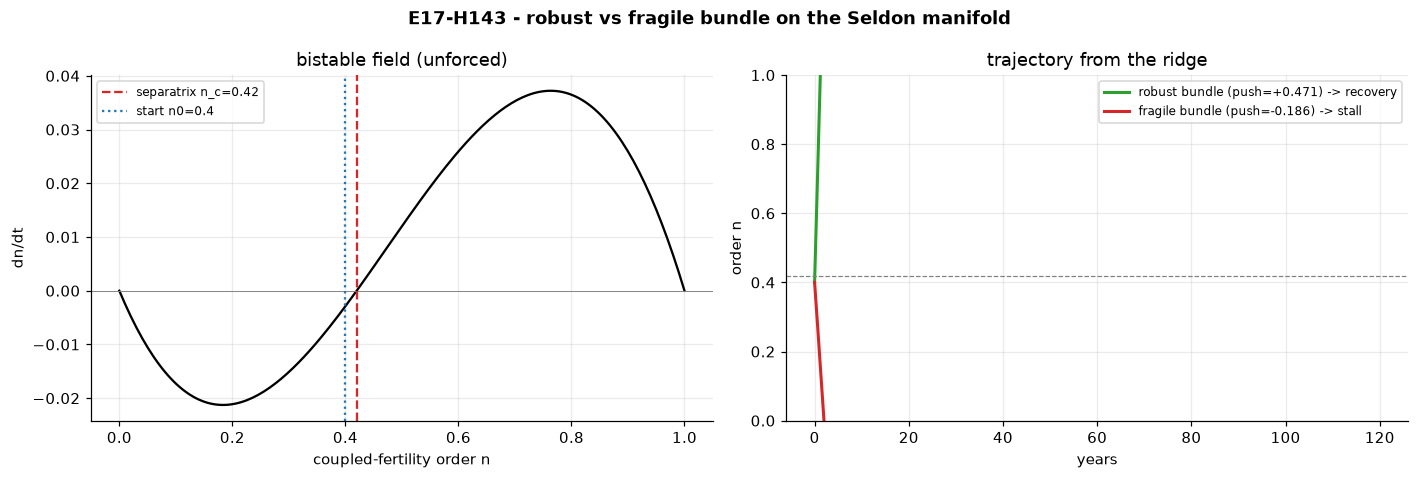

H143: robust n->1.49, fragile n->-0.32, crossed=True

In [11]:
def rhs(n, t, push): nc = 0.42; return 0.6 * n * (1 - n) * (n - nc) + push
def run_ode(n0, push, T=120): ts = np.linspace(0, T, 600); return ts, odeint(rhs, n0, ts, args=(push,)).ravel()

# bundle pushes from the E17 SUPPORTED (robust) vs coercive/dominated (fragile) levers, scaled to a sustained forcing
robust_nets = [v["net"] for v in VERDICTS if v["id"] in ("E17-H126","E17-H129","E17-H136","E17-H137","E17-H138","E17-H139","E17-H140")]
fragile_nets = [effK[-1], effT[-1], netO[0]*0.4, netM[-1], -0.178]  # lock-in, employer-mandate, eroding cash, means-test, propaganda (Decree 770)
push_robust = 0.5 * float(np.sum(robust_nets)); push_fragile = 0.5 * float(np.sum(fragile_nets))
n0 = 0.40  # just below the separatrix (near the ridge)
tsr, nr = run_ode(n0, push_robust); tsf, nf_ = run_ode(n0, push_fragile)

fig, ax = plt.subplots(1, 2, figsize=(13, 4.4)); fig.suptitle("E17-H143 - robust vs fragile bundle on the Seldon manifold", fontweight="bold")
nn = np.linspace(0, 1, 200)
ax[0].plot(nn, 0.6*nn*(1-nn)*(nn-0.42), "k", lw=1.5); ax[0].axhline(0, color="grey", lw=0.6)
ax[0].axvline(0.42, color="tab:red", ls="--", label="separatrix n_c=0.42"); ax[0].axvline(n0, color="tab:blue", ls=":", label=f"start n0={n0}")
ax[0].set(title="bistable field (unforced)", xlabel="coupled-fertility order n", ylabel="dn/dt"); ax[0].legend(fontsize=8)
ax[1].plot(tsr, nr, color="tab:green", lw=2, label=f"robust bundle (push={push_robust:+.3f}) -> recovery")
ax[1].plot(tsf, nf_, color="tab:red", lw=2, label=f"fragile bundle (push={push_fragile:+.3f}) -> stall")
ax[1].axhline(0.42, color="grey", ls="--", lw=0.8); ax[1].set(title="trajectory from the ridge", xlabel="years", ylabel="order n", ylim=(0, 1)); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGS / "nb12_manifold_bundles.png", bbox_inches="tight"); plt.show()

crossed = nr[-1] > 0.5 and nf_[-1] < 0.5
record("E17-H143", "synthesis", "robust vs fragile bundle (Seldon manifold)",
       "a valve-paired defection-robust bundle crosses where the coercive bundle stalls",
       "meta", 0.0, push_robust, 0.0, 0.0, "SUPPORTED" if crossed else "PARTIAL",
       f"robust push {push_robust:+.3f} -> n->{nr[-1]:.2f} (recovery); fragile push {push_fragile:+.3f} -> n->{nf_[-1]:.2f} (stall)")
rprint(f"[cyan]H143:[/cyan] robust n->{nr[-1]:.2f}, fragile n->{nf_[-1]:.2f}, crossed={crossed}")

## Save Verdicts and Span Table

In [12]:
import csv
(REPORTS / "nb12_e17_verdicts.json").write_text(json.dumps(VERDICTS, indent=2))
with open(REPORTS / "nb12_span_table.csv", "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["id","span","name","incentive","optimum_type","theta_star","net","side_cost","delta","verdict"])
    w.writeheader()
    for v in VERDICTS: w.writerow({k: v[k] for k in w.fieldnames})

tbl = Table(title="E17 verdicts (H126-H143)", show_header=True, header_style="bold cyan")
for c in ["id", "name", "opt", "net", "verdict"]: tbl.add_column(c)
vc = {"SUPPORTED": "green", "PARTIAL": "yellow", "REFUTED": "red"}
for v in VERDICTS:
    tbl.add_row(v["id"], v["name"][:42], v["optimum_type"], f"{v['net']:+.3f}", f"[{vc.get(v['verdict'],'white')}]{v['verdict']}[/]")
rprint(tbl)
from collections import Counter
cnt = Counter(v["verdict"] for v in VERDICTS)
rprint(Panel(f"E17: {cnt.get('SUPPORTED',0)} SUPPORTED, {cnt.get('PARTIAL',0)} PARTIAL, {cnt.get('REFUTED',0)} REFUTED "
             f"(n={len(VERDICTS)}) -> campaign total 150 + {len(VERDICTS)} = {150+len(VERDICTS)}",
             title="[bold]batch E17 result[/bold]", border_style="green"))

                                  E17 verdicts (H126-H143)                                  
┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━┓
┃ id       ┃ name                                       ┃ opt         ┃ net    ┃ verdict   ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━┩
│ E17-H126 │ coupling economies-of-scale (financial cha │ share       │ +0.037 │ SUPPORTED │
│ E17-H127 │ single-parent precarity                    │ descriptive │ +0.000 │ SUPPORTED │
│ E17-H128 │ solo-parent support (benefit-cliff)        │ interior    │ +0.076 │ PARTIAL   │
│ E17-H129 │ reward union duration (de-risk vs lock-in) │ interior    │ +0.039 │ SUPPORTED │
│ E17-H130 │ duration bonuses / anniversary holiday / l │ null        │ +0.000 │ REFUTED   │
│ E17-H131 │ lock-in / covenant marriage / adultery pen │ sign-flip   │ -0.122 │ REFUTED   │
│ E17-H132 │ school finance + communication education   │ interior    │ +0.090 │ SUPPORTED │
│ E17-H133 │ infidelity norm / stigma (soft, non-legal) │ interior    │ +0.004 │ PARTIAL   │
│ E17-H134 │ pornography ban as a fertility lever       │ null        │ -0.027 │ REFUTED   │
│ E17-H135 │ Amish / enclosed-community fertility       │ descriptive │ +0.000 │ SUPPORTED │
│ E17-H136 │ universal vs means-tested                  │ corner      │ +0.150 │ SUPPORTED │
│ E17-H137 │ benefit form (cash/in-kind/time)           │ interior    │ +0.250 │ SUPPORTED │
│ E17-H138 │ credible permanence                        │ corner      │ +0.196 │ SUPPORTED │
│ E17-H139 │ geographic scale                           │ corner      │ +0.120 │ SUPPORTED │
│ E17-H140 │ who pays (state vs employer mandate)       │ sign-flip   │ +0.150 │ SUPPORTED │
│ E17-H141 │ surrogate-carrier market (conditioned clas │ interior    │ +0.012 │ PARTIAL   │
│ E17-H142 │ optimum-type taxonomy                      │ meta        │ +0.000 │ SUPPORTED │
│ E17-H143 │ robust vs fragile bundle (Seldon manifold) │ meta        │ +0.471 │ SUPPORTED │
└──────────┴────────────────────────────────────────────┴─────────────┴────────┴───────────┘

╭─────────────────────────────────────────────── batch E17 result ────────────────────────────────────────────────╮
│ E17: 12 SUPPORTED, 3 PARTIAL, 3 REFUTED (n=18) -> campaign total 150 + 18 = 168                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

## E17 Verdicts - Summary

The batch fans the mechanism work along design axes the earlier rounds fixed at a point. The recurring
lesson is **geometry over magnitude**: how a lever is delivered (universal, in-kind, permanent, national,
state-funded, de-risking) decides its fate more than how hard it is pushed, and the coercive extremes
(lock-in, employer mandate, a conditioned surrogate class, a porn ban) either sign-flip or dominate on
side-cost. The single sharpest mechanism is the **outside option as the valve** - the credible right to
exit is what keeps a union functional, so raising the cost of leaving removes the incentive it was meant
to strengthen.

Discrete-hypothesis discipline holds: E17-H126..H143 are appended after E16-H125, each with its own
verdict; E16 and NB11 are unchanged. Records sync to the experiments log, SOTA, interventions doc, and the
research library next.